# ClonalOrigin model and simulation-based inference

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils.torchutils import BoxUniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Observation data, simulator and prior

**Simulate observed data**

Set the true parameters as
* $\rho_s = 0.02$,
* $\delta = 300$,
* $\theta_s = 0.05$.

**Define prior distribution**

We set the prior to be uniform with range:
* $[0, 0.2]$ for $\rho_s$,
* $[1, 500]$ for $\delta$,
* $[0, 0.2]$ for $\theta_s$.

In [3]:
prior = BoxUniform(
    low=torch.tensor([0.0, 1.0, 0.0], device=torch_device),
    high=torch.tensor([0.2, 500.0, 0.2], device=torch_device), 
    device=torch_device
)

In [8]:
x_o_numpy = np.loadtxt('../data/ClonalOrigin/x_o.csv', delimiter=",")
x_o = torch.tensor(x_o_numpy, device=torch_device)
x_o = x_o.float()
x_o

tensor([0.0046, 0.0048, 0.0024, 0.0000, 0.0020, 0.0015, 0.1452])

In [10]:
x_numpy = np.loadtxt('../data/ClonalOrigin/x.csv', delimiter=",")
x = torch.tensor(x_numpy, device=torch_device)
x

tensor([[0.0153, 0.0101, 0.0092,  ..., 0.0105, 0.0115, 0.2898],
        [0.0332, 0.0215, 0.0165,  ..., 0.0180, 0.0160, 0.3712],
        [0.0690, 0.0462, 0.0350,  ..., 0.0865, 0.0880, 0.6205],
        ...,
        [0.0203, 0.0146, 0.0142,  ..., 0.0070, 0.0040, 0.2897],
        [0.0107, 0.0076, 0.0108,  ..., 0.0020, 0.0040, 0.2173],
        [0.0592, 0.0374, 0.0280,  ..., 0.0595, 0.0570, 0.5532]],
       dtype=torch.float64)

In [12]:
theta_numpy = np.loadtxt('../data/ClonalOrigin/theta.csv', delimiter=",")
theta = torch.tensor(theta_numpy, device=torch_device)
theta

tensor([[1.4161e-01, 5.7735e+01, 1.0255e-01],
        [3.7611e-02, 1.2744e+02, 1.7380e-01],
        [1.5440e-01, 2.8293e+02, 1.7661e-01],
        ...,
        [2.9189e-02, 6.7247e+01, 1.8062e-01],
        [2.7224e-02, 8.6056e+01, 1.1132e-01],
        [8.0962e-02, 3.9007e+02, 1.6421e-01]], dtype=torch.float64)

## Visualisation

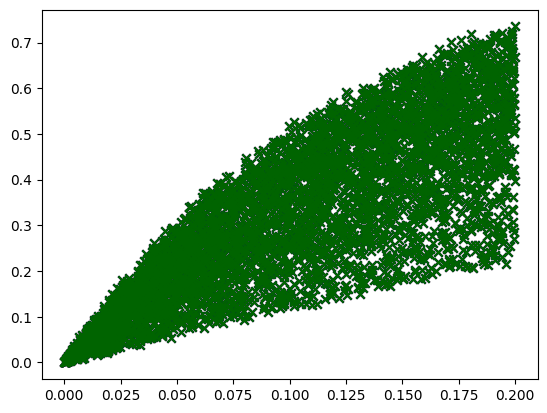

In [22]:
plt.scatter(theta_numpy[:, 2], x_numpy[:, 6], marker='x', color='darkred')
plt.scatter(theta_numpy[:, 2], x_numpy[:, 6], marker='x', color='darkblue')
plt.scatter(theta_numpy[:, 2], x_numpy[:, 6], marker='x', color='darkgreen')

# Display the plot
plt.show()

## NPE-C

In [2]:
simulation_budget = 5000
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

NameError: name 'prior' is not defined